In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/euclidean_distances.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/euclidean_distances.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/euclidean_distances.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/euclidean_distances.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/euclidean_distances.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/euclidean_distances.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


In [2]:
# clean labels for plotting
condition_order = [
    'GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved',
    'SI Fed-Fed', 'SI Fed-Starved', 'SI Starved-Starved'
]

palette = {
    'GH Fed-Fed': '#2F6F4E',
    'GH Fed-Starved': '#7A5BA6',
    'GH Starved-Starved': '#B84E4E',
    'SI Fed-Fed': '#8BC49A',
    'SI Fed-Starved': '#C3A6D8',
    'SI Starved-Starved': '#E39A93',
}

df['Housing'] = np.where(df['Condition'].str.contains('GH'), 'GH', 'SI')
df['Feeding'] = df['Condition'].str.replace('GH ', '', regex=False).str.replace('SI ', '', regex=False)

df.head()


,time,average_distance,file,Condition,Housing,Feeding
0,0,73.756138,2026-04-28_12-19-24_td11.tracks.feather,GH Fed-Fed,GH,Fed-Fed
1,0,71.677464,2026-04-28_12-20-56_td13.tracks.feather,GH Fed-Fed,GH,Fed-Fed
2,0,73.120041,2026-04-28_15-17-04_td10.tracks.feather,GH Fed-Fed,GH,Fed-Fed
3,0,71.506852,2026-04-28_15-18-47_td11.tracks.feather,GH Fed-Fed,GH,Fed-Fed
4,0,70.538340,2026-04-28_15-20-06_td12.tracks.feather,GH Fed-Fed,GH,Fed-Fed


In [3]:
# one value per file, so files with more frames do not dominate the boxes
file_summary = df.groupby(['Condition', 'Housing', 'Feeding', 'file']).agg(
    median_distance=('average_distance', 'median'),
    mean_distance=('average_distance', 'mean'),
    min_distance=('average_distance', 'min'),
    start_distance=('average_distance', 'first'),
    end_distance=('average_distance', 'last'),
).reset_index()

file_summary['distance_change'] = file_summary['end_distance'] - file_summary['start_distance']

file_summary.groupby(['Housing', 'Feeding']).size()


Housing  Feeding        
GH       Fed-Fed            26
         Fed-Starved        28
         Starved-Starved    20
SI       Fed-Fed            25
         Fed-Starved        19
         Starved-Starved    19
dtype: int64

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_5731/348389707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


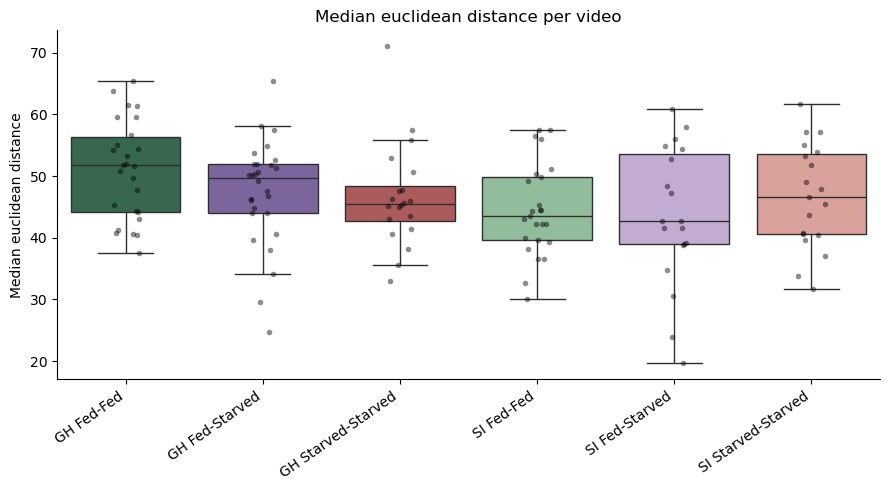

In [4]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=file_summary,
    x='Condition',
    y='median_distance',
    order=condition_order,
    palette=palette,
    showfliers=False,
)
sns.stripplot(
    data=file_summary,
    x='Condition',
    y='median_distance',
    order=condition_order,
    color='black',
    alpha=0.45,
    size=4,
)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Median euclidean distance')
plt.xlabel('')
plt.title('Median euclidean distance per video')
sns.despine()
plt.tight_layout()
plt.show()


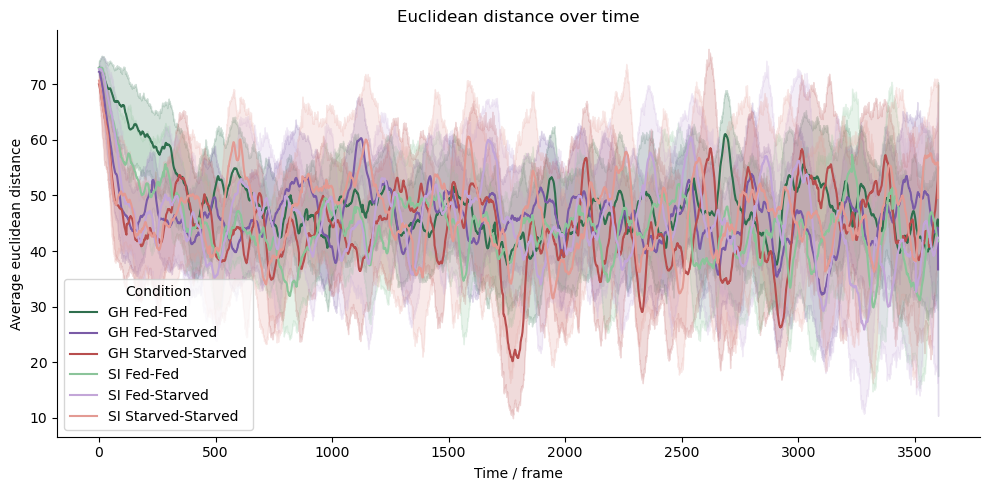

In [7]:
# average distance trace over time
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x='time',
    y='average_distance',
    hue='Condition',
    hue_order=condition_order,
    palette=palette,
    errorbar=('ci', 95),
)
plt.ylabel('Average euclidean distance')
plt.xlabel('Time / frame')
plt.title('Euclidean distance over time')
sns.despine()
plt.tight_layout()
plt.show()


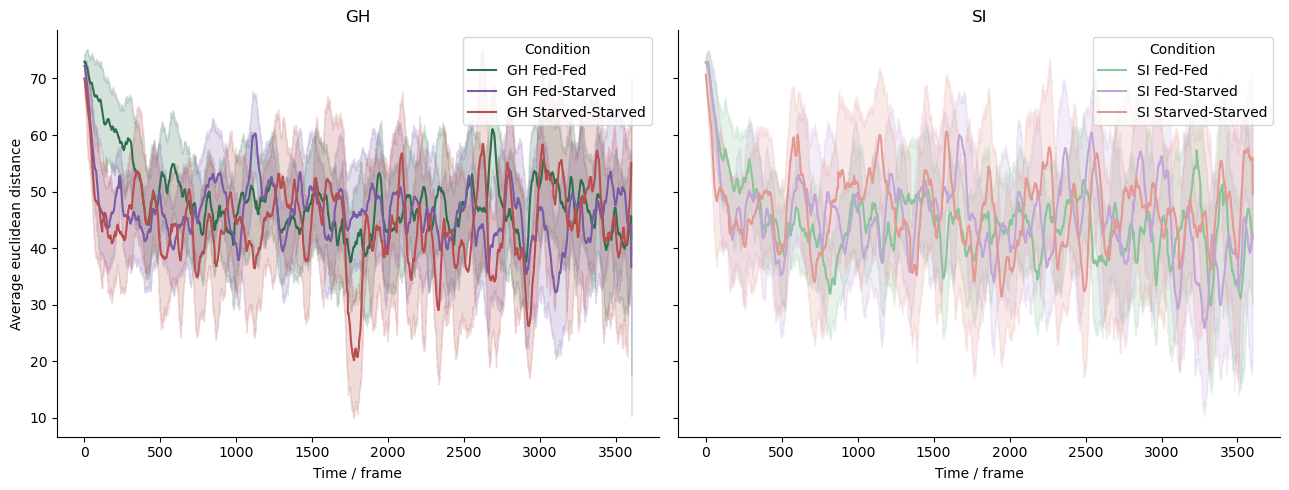

In [8]:
# same trace split by housing, easier to read
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, housing in zip(axes, ['GH', 'SI']):
    sub = df[df['Housing'] == housing]
    order = [c for c in condition_order if c.startswith(housing)]
    sns.lineplot(
        data=sub,
        x='time',
        y='average_distance',
        hue='Condition',
        hue_order=order,
        palette=palette,
        errorbar=('ci', 95),
        ax=ax,
    )
    ax.set_title(housing)
    ax.set_ylabel('Average euclidean distance')
    ax.set_xlabel('Time / frame')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_5731/3664846194.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


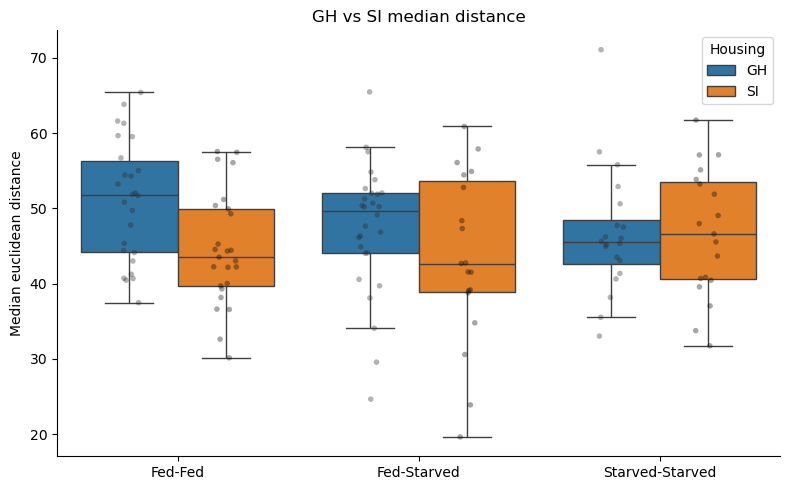

In [9]:
# GH vs SI directly within each feeding condition
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=file_summary,
    x='Feeding',
    y='median_distance',
    hue='Housing',
    order=['Fed-Fed', 'Fed-Starved', 'Starved-Starved'],
    hue_order=['GH', 'SI'],
    showfliers=False,
)
sns.stripplot(
    data=file_summary,
    x='Feeding',
    y='median_distance',
    hue='Housing',
    order=['Fed-Fed', 'Fed-Starved', 'Starved-Starved'],
    hue_order=['GH', 'SI'],
    dodge=True,
    color='black',
    alpha=0.35,
    size=4,
    legend=False,
)
plt.ylabel('Median euclidean distance')
plt.xlabel('')
plt.title('GH vs SI median distance')
sns.despine()
plt.tight_layout()
plt.show()
